# Jacobian unit-test figures — Test Case B

Figures for **Test Case B** of `tests/test_jacobian.py`
(`test_jacobian_90deg_rotation_sign_conventions`).

**Idea.** With a quarter-turn grid rotation (`CS=0, SN=1`) the
geographic Jacobian is `R . J_model . R^T = [[f, -e], [-b, a]]`.
The swapped roles and flipped signs make this the sharpest check
of the rotation sign conventions. We reuse the test fixtures to
build the data and `tj.analytic_rotated_jacobian` for the targets.

Generated by JXP and Claude

In [1]:
# Imports at top (project convention). We import the test module itself so
# the figures are generated from the very same fixtures, parameters and
# assertions used by tests/test_jacobian.py.
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import dbof.utils.native_gradient as ng

# Make the repository's tests/ importable, then reuse its code.
_REPO = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
_TESTS = os.path.join(_REPO, 'tests')
if _TESTS not in sys.path:
    sys.path.insert(0, _TESTS)

import test_jacobian as tj  # noqa: E402

print('EDGE_MARGIN =', tj.EDGE_MARGIN, '| N_FACES =', tj.N_FACES)


EDGE_MARGIN = 3 | N_FACES = 13


## 1. Build the data and run `calculate_jacobian`

Same parameters as Test Case B: `CS=0, SN=1`, `d=2500 m`, linear
velocity slopes `(a, b, e, f)`.

In [2]:
d = 2500.0
a, b, e, f = 1.0e-5, 2.0e-5, -3.0e-5, 4.0e-5

# 90-degree rotation: CS=0, SN=1.
ds, grid = tj.make_synthetic_grid(n=16, d=d, cs=0.0, sn=1.0)
u_x, v_y = tj.add_linear_velocity(ds, d, a, b, e, f)
dudl, dudp, dvdl, dvdp = ng.calculate_jacobian(u_x, v_y, ds, grid)

# Analytic targets [[f, -e], [-b, a]] from the test's own helper.
targets = tj.analytic_rotated_jacobian(a, b, e, f, cs=0.0, sn=1.0)
labels = [r'$\partial u_\lambda/\partial \lambda$',
          r'$\partial u_\lambda/\partial \phi$',
          r'$\partial v_\phi/\partial \lambda$',
          r'$\partial v_\phi/\partial \phi$']
expr = ['f', '-e', '-b', 'a']
components = list(zip([dudl, dudp, dvdl, dvdp], targets, labels, expr))
FACE = 0
for lab, t, ex in zip(labels, targets, expr):
    print(f'{lab} -> {ex} = {t:.1e}')


$\partial u_\lambda/\partial \lambda$ -> f = 4.0e-05
$\partial u_\lambda/\partial \phi$ -> -e = 3.0e-05
$\partial v_\phi/\partial \lambda$ -> -b = -2.0e-05
$\partial v_\phi/\partial \phi$ -> a = 1.0e-05


## 2. Computed components vs. their 90-degree targets

Each interior is constant and equals the rotated-tensor entry
(`f`, `-e`, `-b`, `a`). The dashed box is the `EDGE_MARGIN`
interior the test asserts on.

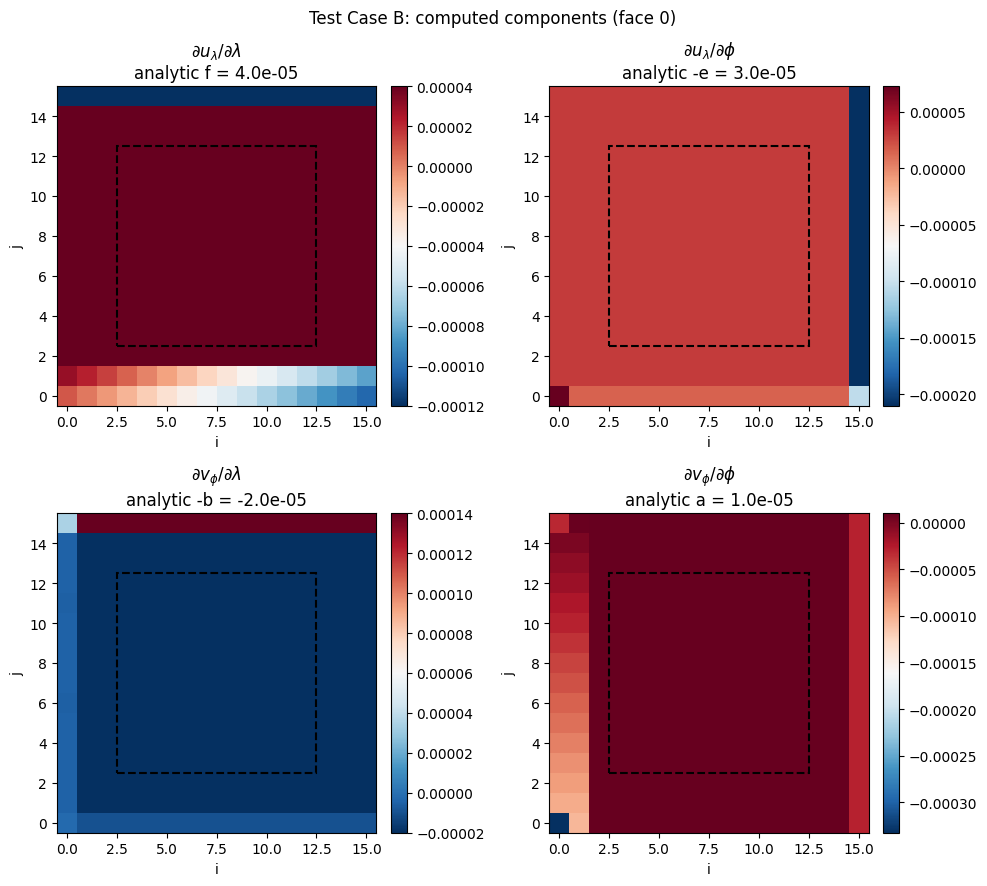

In [3]:
m = tj.EDGE_MARGIN
n = ds.sizes['i']
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, (da, t, lab, ex) in zip(axes.ravel(), components):
    pcm = ax.imshow(da.isel(face=FACE).values, origin='lower', cmap='RdBu_r')
    fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.04)
    ax.add_patch(Rectangle((m - 0.5, m - 0.5), n - 2 * m, n - 2 * m,
                           fill=False, ec='k', ls='--', lw=1.5))
    ax.set_title(f'{lab}\nanalytic {ex} = {t:.1e}')
    ax.set_xlabel('i'); ax.set_ylabel('j')
fig.suptitle('Test Case B: computed components (face %d)' % FACE)
fig.tight_layout(); plt.show()


## 3. The sign-convention check, made explicit

Bars compare the computed interior mean against the analytic
90-degree target for each component. The point of Case B is the
**signs**: `du/dφ = -e > 0` and `dv/dλ = -b < 0` both flip
relative to the model-basis slopes.

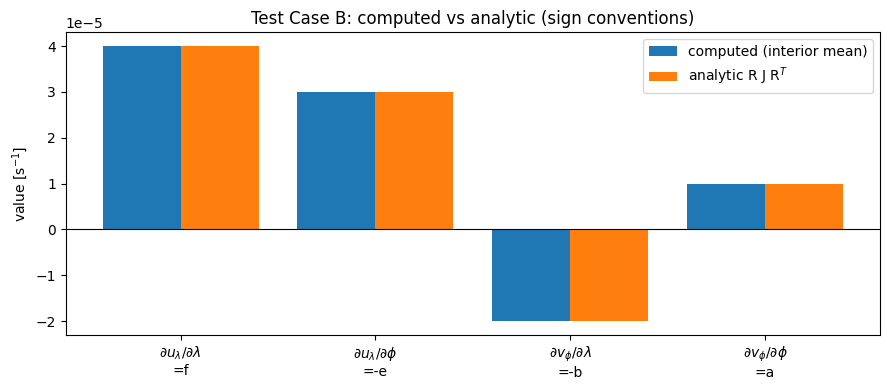

J_model =
 [[ 1.e-05  2.e-05]
 [-3.e-05  4.e-05]]
R(90) J R(90)^T =
 [[ 4.e-05  3.e-05]
 [-2.e-05  1.e-05]]


In [4]:
comp_means = [float(tj.interior(da).values.mean()) for da, *_ in components]
x = np.arange(4)
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - 0.2, comp_means, width=0.4, label='computed (interior mean)')
ax.bar(x + 0.2, targets, width=0.4, label='analytic R J R$^T$')
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'{lab}\n={ex}' for _, _, lab, ex in components])
ax.set_ylabel('value [s$^{-1}$]')
ax.set_title('Test Case B: computed vs analytic (sign conventions)')
ax.legend(); fig.tight_layout(); plt.show()

# Print the model-frame vs rotated tensors side by side.
J_model = np.array([[a, b], [e, f]])
J_rot = np.array([[targets[0], targets[1]], [targets[2], targets[3]]])
print('J_model =\n', J_model)
print('R(90) J R(90)^T =\n', J_rot)


## 4. Run the actual unit test

No exception means Test Case B passes.

In [5]:
tj.test_jacobian_90deg_rotation_sign_conventions()
print('Test Case B passed.')


Test Case B passed.
